Running 5-fold CV for SVM (this may take a few minutes)...
MODEL 4: Support Vector Machine (RBF Kernel)
              precision    recall  f1-score   support

  No Failure       1.00      0.96      0.98      9661
     Failure       0.46      0.91      0.61       339

    accuracy                           0.96     10000
   macro avg       0.73      0.94      0.79     10000
weighted avg       0.98      0.96      0.97     10000

Macro F1 Score : 0.7933  (target ≥ 0.85)
ROC-AUC Score  : 0.9717

--- Noise Sensitivity Test ---
  Noise σ=0.00 → Macro F1=0.7918
  Noise σ=0.05 → Macro F1=0.7886
  Noise σ=0.10 → Macro F1=0.7850
  Noise σ=0.20 → Macro F1=0.7691


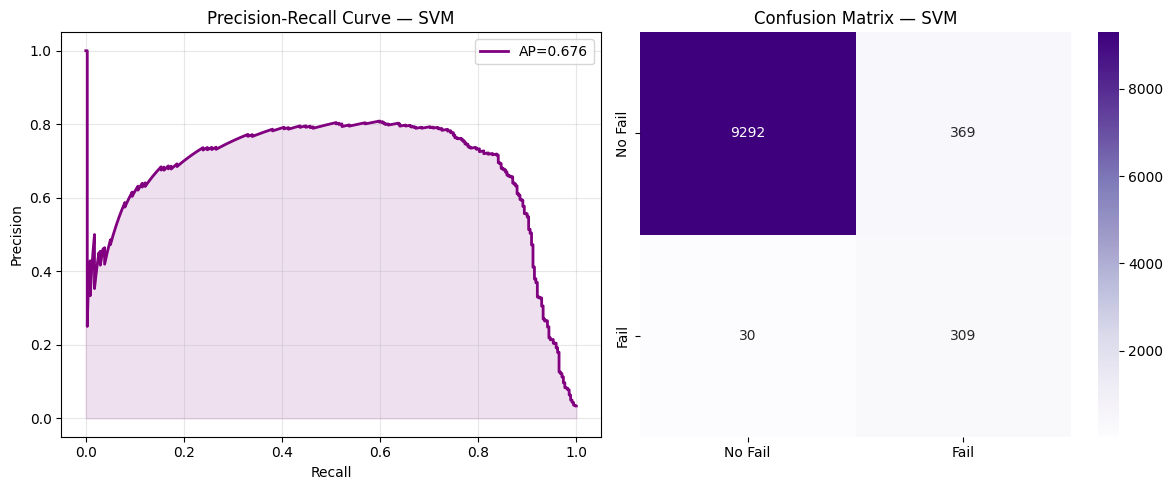


✅ Model 4 complete.


In [1]:
# ============================================================
# MODEL 4 — Support Vector Machine (RBF Kernel)
# Day 4 commit | Effective in high-dimensional scaled space
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, f1_score,
                              roc_auc_score, average_precision_score,
                              precision_recall_curve, confusion_matrix)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

# ---- DATA & FEATURES ----
df = pd.read_csv('/kaggle/input/datasets/zenishadevani/intern/ai4i2020 (1).csv')
df.drop(columns=['UDI', 'Product ID'], inplace=True)
le = LabelEncoder()
df['Type_enc'] = le.fit_transform(df['Type'])
df.drop(columns=['Type'], inplace=True)

df['Temp_diff']     = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power_W']       = df['Torque [Nm]'] * (df['Rotational speed [rpm]'] * 2 * np.pi / 60)
df['Wear_x_Torque'] = df['Tool wear [min]'] * df['Torque [Nm]']
df['Stress_proxy']  = df['Torque [Nm]'] / (df['Rotational speed [rpm]'] + 1e-6)
df['HDF_cond']      = ((df['Temp_diff'] < 8.6) & (df['Rotational speed [rpm]'] < 1380)).astype(int)
df['PWF_cond']      = ((df['Power_W'] < 3500) | (df['Power_W'] > 9000)).astype(int)
df['OSF_cond']      = (df['Wear_x_Torque'] > 11000).astype(int)

TARGET = 'Machine failure'
FAILURE_COLS = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
feature_cols = [c for c in df.columns if c not in [TARGET] + FAILURE_COLS]
X = df[feature_cols]
y = df[TARGET]

# ---- PIPELINE ----
# SVM requires scaling — StandardScaler is critical here
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    SVC(
                   C=10,
                   kernel='rbf',
                   gamma='scale',
                   class_weight='balanced',
                   probability=True,   # needed for predict_proba
                   random_state=42))
])

# ---- CROSS-VALIDATION ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Running 5-fold CV for SVM (this may take a few minutes)...")
y_pred = cross_val_predict(pipeline, X, y, cv=cv, method='predict')
y_prob = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba')[:, 1]

print("=" * 60)
print("MODEL 4: Support Vector Machine (RBF Kernel)")
print("=" * 60)
print(classification_report(y, y_pred, target_names=['No Failure', 'Failure']))
macro_f1 = f1_score(y, y_pred, average='macro')
roc_auc  = roc_auc_score(y, y_prob)
print(f"Macro F1 Score : {macro_f1:.4f}  (target ≥ 0.85)")
print(f"ROC-AUC Score  : {roc_auc:.4f}")

# ---- NOISE SENSITIVITY (Week 4 preview) ----
print("\n--- Noise Sensitivity Test ---")
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      stratify=y, random_state=42)
pipeline.fit(X_train, y_train)

for noise_level in [0.0, 0.05, 0.10, 0.20]:
    X_noisy = X_test.copy().values.astype(float)
    if noise_level > 0:
        noise = np.random.normal(0, noise_level * X_noisy.std(axis=0), X_noisy.shape)
        X_noisy += noise
    X_noisy_df = pd.DataFrame(X_noisy, columns=X_test.columns)
    y_noisy_pred = pipeline.named_steps['clf'].predict(
        pipeline.named_steps['scaler'].transform(X_noisy_df)
    )
    f1_noise = f1_score(y_test, y_noisy_pred, average='macro')
    print(f"  Noise σ={noise_level:.2f} → Macro F1={f1_noise:.4f}")

# ---- PLOTS ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PR Curve
precision, recall, _ = precision_recall_curve(y, y_prob)
ap = average_precision_score(y, y_prob)
axes[0].plot(recall, precision, lw=2, color='purple', label=f'AP={ap:.3f}')
axes[0].fill_between(recall, precision, alpha=0.12, color='purple')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve — SVM')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[1],
            xticklabels=['No Fail', 'Fail'], yticklabels=['No Fail', 'Fail'])
axes[1].set_title('Confusion Matrix — SVM')

plt.tight_layout()
plt.savefig('model4_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Model 4 complete.")